In [1]:
# ============================================================
# SECTION 1: IMPORTS & CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve, f1_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

In [2]:
# ============================================================
# SECTION 2: LOAD & INSPECT DATA
# ============================================================

df = pd.read_csv("Data/Telco-Customer-Churn.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['Churn'].value_counts()}")
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

Dataset shape: (7043, 21)

Class distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


In [3]:
# ============================================================
# SECTION 3: PREPROCESSING — SINGLE CLEAN PIPELINE
# ============================================================

# Drop customer ID — not a feature
df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges — blank strings to NaN, then numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-hot encode multi-category columns
multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
df = pd.get_dummies(df, columns=multi_cols, drop_first=False, dtype=int)

print(f"\nFinal shape after encoding: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")



Final shape after encoding: (7032, 41)
Missing values: 0


In [5]:

# ============================================================
# SECTION 4: FEATURE / TARGET SPLIT + TRAIN/TEST SPLIT
# ============================================================

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify preserves churn ratio
)

# Scale features — required for LogReg to be meaningful
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Apply SMOTE to scaled training data only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"\nBefore SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_res.value_counts().to_dict()}")


Before SMOTE: {0: 4130, 1: 1495}
After SMOTE:  {0: 4130, 1: 4130}


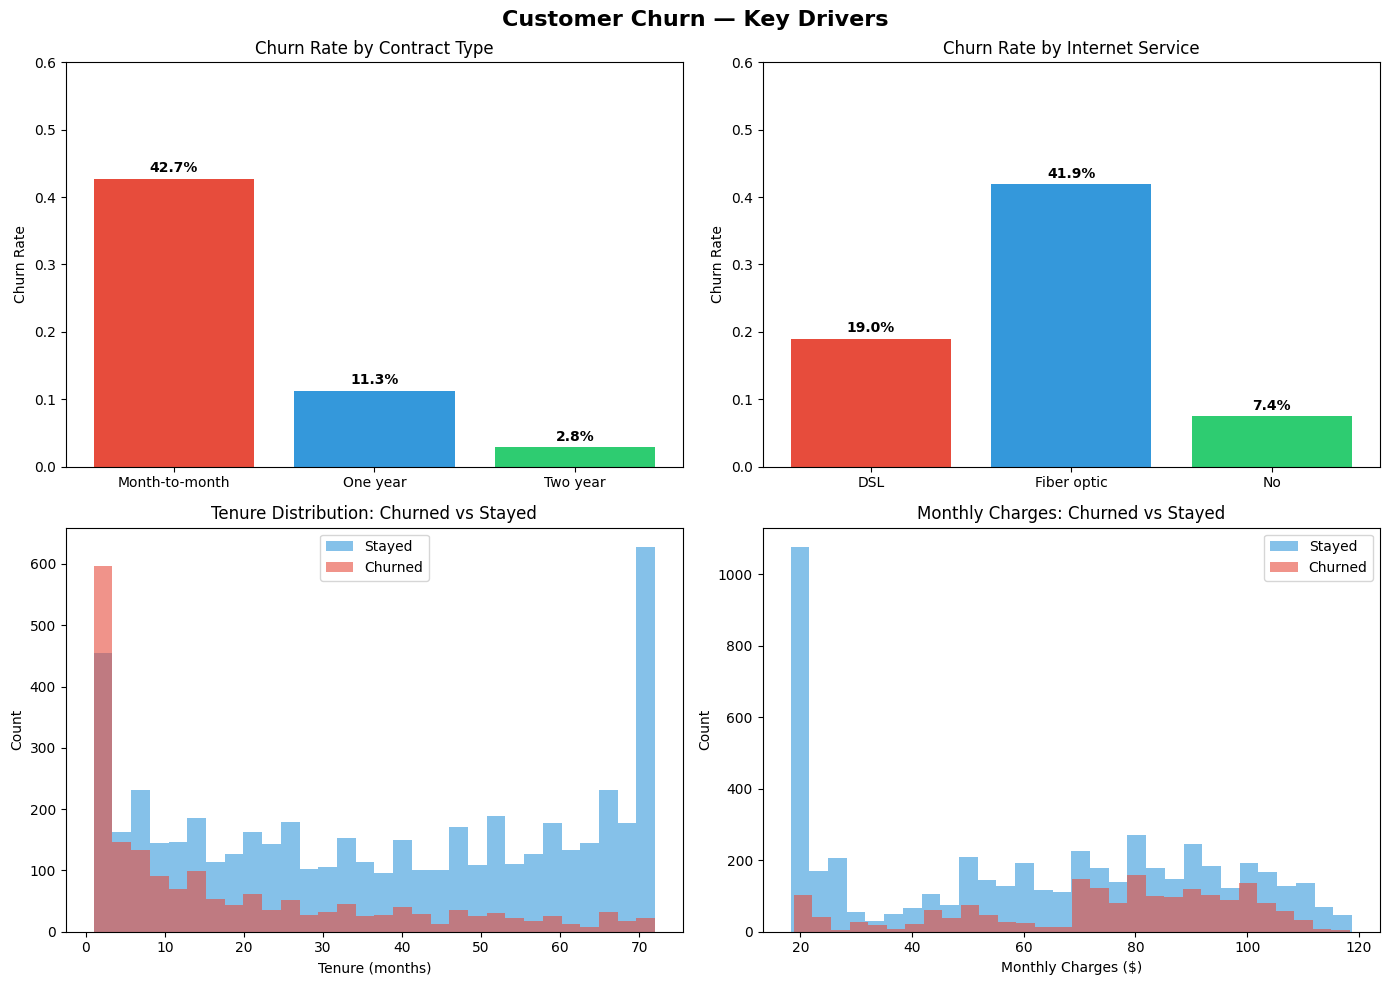


Key Insights:
Month-to-month churn rate: 42.7%
Two-year contract churn rate: 2.8%
Fiber optic churn rate: 41.9%
Avg tenure of churners: 18.0 months
Avg tenure of non-churners: 37.7 months


In [6]:
# ============================================================
# SECTION 5: EDA — TELLING THE CHURN STORY
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Churn — Key Drivers', fontsize=16, fontweight='bold')

# --- Plot 1: Churn Rate by Contract Type ---
contract_cols = [c for c in df.columns if 'Contract' in c]
contract_churn = df[contract_cols + ['Churn']].copy()
contract_churn['Contract_Type'] = contract_churn[contract_cols].idxmax(axis=1).str.replace('Contract_', '')
contract_rate = contract_churn.groupby('Contract_Type')['Churn'].mean().reset_index()
axes[0,0].bar(contract_rate['Contract_Type'], contract_rate['Churn'], color=['#e74c3c','#3498db','#2ecc71'])
axes[0,0].set_title('Churn Rate by Contract Type')
axes[0,0].set_ylabel('Churn Rate')
axes[0,0].set_ylim(0, 0.6)
for i, v in enumerate(contract_rate['Churn']):
    axes[0,0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# --- Plot 2: Churn Rate by Internet Service ---
internet_cols = [c for c in df.columns if 'InternetService' in c]
internet_churn = df[internet_cols + ['Churn']].copy()
internet_churn['Internet_Type'] = internet_churn[internet_cols].idxmax(axis=1).str.replace('InternetService_', '')
internet_rate = internet_churn.groupby('Internet_Type')['Churn'].mean().reset_index()
axes[0,1].bar(internet_rate['Internet_Type'], internet_rate['Churn'], color=['#e74c3c','#3498db','#2ecc71'])
axes[0,1].set_title('Churn Rate by Internet Service')
axes[0,1].set_ylabel('Churn Rate')
axes[0,1].set_ylim(0, 0.6)
for i, v in enumerate(internet_rate['Churn']):
    axes[0,1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# --- Plot 3: Tenure Distribution by Churn ---
axes[1,0].hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.6, label='Stayed', color='#3498db')
axes[1,0].hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.6, label='Churned', color='#e74c3c')
axes[1,0].set_title('Tenure Distribution: Churned vs Stayed')
axes[1,0].set_xlabel('Tenure (months)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# --- Plot 4: Monthly Charges Distribution by Churn ---
axes[1,1].hist(df[df['Churn']==0]['MonthlyCharges'], bins=30, alpha=0.6, label='Stayed', color='#3498db')
axes[1,1].hist(df[df['Churn']==1]['MonthlyCharges'], bins=30, alpha=0.6, label='Churned', color='#e74c3c')
axes[1,1].set_title('Monthly Charges: Churned vs Stayed')
axes[1,1].set_xlabel('Monthly Charges ($)')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('Visualizations/churn_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insights:")
print(f"Month-to-month churn rate: {df[df['Contract_Month-to-month']==1]['Churn'].mean():.1%}")
print(f"Two-year contract churn rate: {df[df['Contract_Two year']==1]['Churn'].mean():.1%}")
print(f"Fiber optic churn rate: {df[df['InternetService_Fiber optic']==1]['Churn'].mean():.1%}")
print(f"Avg tenure of churners: {df[df['Churn']==1]['tenure'].mean():.1f} months")
print(f"Avg tenure of non-churners: {df[df['Churn']==0]['tenure'].mean():.1f} months")

In [7]:
# ============================================================
# SECTION 6: MODEL TRAINING & COMPARISON
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

# --- Model 1: Logistic Regression ---
print("Training Logistic Regression...")
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
lr = LogisticRegression(max_iter=1000)
grid_lr = GridSearchCV(lr, lr_params, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_res, y_train_res)
best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

results['Logistic Regression'] = {
    'model': best_lr,
    'predictions': y_pred_lr,
    'probabilities': y_prob_lr,
    'f1': f1_score(y_test, y_pred_lr),
    'roc_auc': roc_auc_score(y_test, y_prob_lr),
    'cv_score': cross_val_score(best_lr, X_train_res, y_train_res, cv=cv, scoring='roc_auc').mean()
}
print(f"LR done — ROC-AUC: {results['Logistic Regression']['roc_auc']:.3f}")

# --- Model 2: Random Forest ---
print("\nTraining Random Forest...")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}
rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, rf_params, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train_res, y_train_res)
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

results['Random Forest'] = {
    'model': best_rf,
    'predictions': y_pred_rf,
    'probabilities': y_prob_rf,
    'f1': f1_score(y_test, y_pred_rf),
    'roc_auc': roc_auc_score(y_test, y_prob_rf),
    'cv_score': cross_val_score(best_rf, X_train_res, y_train_res, cv=cv, scoring='roc_auc').mean()
}
print(f"RF done — ROC-AUC: {results['Random Forest']['roc_auc']:.3f}")

# --- Model 3: XGBoost ---
print("\nTraining XGBoost...")
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}
xgb = XGBClassifier(
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42
)
grid_xgb = GridSearchCV(xgb, xgb_params, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

results['XGBoost'] = {
    'model': best_xgb,
    'predictions': y_pred_xgb,
    'probabilities': y_prob_xgb,
    'f1': f1_score(y_test, y_pred_xgb),
    'roc_auc': roc_auc_score(y_test, y_prob_xgb),
    'cv_score': cross_val_score(best_xgb, X_train, y_train, cv=cv, scoring='roc_auc').mean()
}
print(f"XGB done — ROC-AUC: {results['XGBoost']['roc_auc']:.3f}")

# --- Summary ---
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
for name, r in results.items():
    print(f"{name:20} | F1: {r['f1']:.3f} | ROC-AUC: {r['roc_auc']:.3f} | CV: {r['cv_score']:.3f}")

Training Logistic Regression...
LR done — ROC-AUC: 0.833

Training Random Forest...
RF done — ROC-AUC: 0.816

Training XGBoost...
XGB done — ROC-AUC: 0.841

MODEL COMPARISON SUMMARY
Logistic Regression  | F1: 0.608 | ROC-AUC: 0.833 | CV: 0.864
Random Forest        | F1: 0.595 | ROC-AUC: 0.816 | CV: 0.928
XGBoost              | F1: 0.618 | ROC-AUC: 0.841 | CV: 0.850
